# **Project Name**    - Brain Tumor MRI Image Classification



##### **Project Type**    - EDA/Regression/Classification/Unsupervised


# **Project Summary -**

This project focuses on brain tumor detection using MRI image classification, where the goal is to accurately identify and classify images into one of **three tumor types**—commonly Meningioma, Glioma, and Pituitary—as well as a **non-tumor class**. The dataset consists of labeled MRI scans, and the images are preprocessed by resizing, normalization, and one-hot encoding of labels. Three different deep learning models were implemented and compared: a custom CNN model built from scratch, a ResNet50-based transfer learning model, and an InceptionV3-based model. Each model was trained on the same dataset split to ensure a fair comparison, with early convolutional layers frozen for transfer models and classification heads added for fine-tuning. The models were compiled using the categorical crossentropy loss and Adam optimizer and trained for a fixed number of epochs with validation tracking.

Performance evaluation was done through accuracy, loss curves, confusion matrices, and classification reports. The InceptionV3 model, using a 299x299 input shape as required, showed the best validation accuracy and class separation, outperforming both the custom CNN and ResNet50 models. t-SNE visualization was applied to the final layer features to better understand how the models separated the tumor types in reduced dimensions. Visual inspection of predictions helped in identifying edge cases and understanding misclassifications. Overall, the use of transfer learning significantly improved performance on this multi-class medical classification task, demonstrating its strength when working with a relatively limited dataset. The final conclusion highlights InceptionV3 as the most promising architecture for accurate and reliable tumor type classification from brain MRI scans.


# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


This project aims to develop a deep learning-based solution for classifying brain MRI images into multiple categories according to tumor type. It involves building a custom CNN model from scratch and enhancing performance through transfer learning using pretrained models. The project also includes deploying a user-friendly Streamlit web application to enable real-time tumor type predictions from uploaded MRI images.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import os 
from PIL import Image
from sklearn.manifold import TSNE
from matplotlib_venn import venn3
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout,GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import InceptionV3
import keras_tuner as kt


### Dataset Loading

In [3]:
# Load Dataset
train_df = pd.read_csv("C:/Users/Mayank Goel/Downloads/Brain Tumor MRI Image Classification/train/_classes.csv")
test_df = pd.read_csv("C:/Users/Mayank Goel/Downloads/Brain Tumor MRI Image Classification/test/_classes.csv")
valid_df = pd.read_csv("C:/Users/Mayank Goel/Downloads/Brain Tumor MRI Image Classification/valid/_classes.csv")

### Dataset First View

In [4]:
train_df.head()

,filename,Glioma,Meningioma,No Tumor,Pituitary
0,Tr-pi_0164_jpg.rf.000776527ec0acdc89e31e15a352...,0,0,0,1
1,Tr-no_0426_jpg.rf.0026b06f369c5d51aca4c4c9beba...,0,0,1,0
2,Tr-gl_0496_jpg.rf.010620fbbbaa509aa81d7ce5bdf7...,1,0,0,0
3,Tr-gl_0554_jpg.rf.010a72c1c25cc9ce83c77fbb23db...,1,0,0,0
4,Tr-me_0185_jpg.rf.0094b0b539582e2f95ae7b6ada4d...,0,1,0,0


In [5]:
test_df.head()

,filename,Glioma,Meningioma,No Tumor,Pituitary
0,Tr-me_0044_jpg.rf.0223369274dd825d3ff27ace105f...,0,1,0,0
1,Tr-gl_0094_jpg.rf.1c0f0e197cfcf7728469ebc07bc6...,1,0,0,0
2,Tr-pi_0130_jpg.rf.15adee5c88949e10f62a9c54294a...,0,0,0,1
3,Tr-gl_0386_jpg.rf.1323d579421a7a8b821ce882e2a0...,1,0,0,0
4,Tr-no_0477_jpg.rf.19bfdb70a263ae878bd1a2b39719...,0,0,1,0


In [6]:
valid_df.head()

,filename,Glioma,Meningioma,No Tumor,Pituitary
0,Tr-me_0034_jpg.rf.623f1cc8f30e4ef5baa02759f4f9...,0,1,0,0
1,Tr-pi_0310_jpg.rf.6a7af3a7e47e29504b29815e7e25...,0,0,0,1
2,Tr-gl_0239_jpg.rf.6e5cff37515b73707663e8ff1537...,1,0,0,0
3,Tr-no_0052_jpg.rf.6a63634edac060a9076b23ce6f6f...,0,0,1,0
4,Tr-gl_0550_jpg.rf.667b7e2e928c9e4ac209da273de2...,1,0,0,0


### Dataset Rows & Columns count

In [7]:
# Dataset Rows & Columns count
r1,c1 = train_df.shape
r2,c2 = test_df.shape
r3,c3 = valid_df.shape
print(f"Training Dataset --")
print(f"Rows:{r1}   Columns:{c1}")

print(f"Test Dataset --")
print(f"Rows:{r2}   Columns:{c2}")

print(f"Valid Dataset --")
print(f"Rows:{r3}   Columns:{c3}")

Training Dataset --
Rows:1695   Columns:5
Test Dataset --
Rows:246   Columns:5
Valid Dataset --
Rows:502   Columns:5


### Dataset Information

In [8]:
# Dataset Info
train_df.info

<bound method DataFrame.info of                                                filename   Glioma   Meningioma  \
0     Tr-pi_0164_jpg.rf.000776527ec0acdc89e31e15a352...        0            0   
1     Tr-no_0426_jpg.rf.0026b06f369c5d51aca4c4c9beba...        0            0   
2     Tr-gl_0496_jpg.rf.010620fbbbaa509aa81d7ce5bdf7...        1            0   
3     Tr-gl_0554_jpg.rf.010a72c1c25cc9ce83c77fbb23db...        1            0   
4     Tr-me_0185_jpg.rf.0094b0b539582e2f95ae7b6ada4d...        0            1   
...                                                 ...      ...          ...   
1690  Tr-pi_0266_jpg.rf.be96620d2e87b7d1278a7cdebc31...        0            0   
1691  Tr-no_0474_jpg.rf.bf5869c9603ce71575b58df92ca1...        0            0   
1692  Tr-me_0356_jpg.rf.be4ba7e5211c086bdfb21a53ee6b...        0            1   
1693  Tr-gl_0169_jpg.rf.bf25b05a8345a96e51560f67eed7...        1            0   
1694  Tr-pi_0167_jpg.rf.bf3a10b82161ca3042c8e481b9c3...        0            0

In [9]:
test_df.info

<bound method DataFrame.info of                                               filename   Glioma   Meningioma  \
0    Tr-me_0044_jpg.rf.0223369274dd825d3ff27ace105f...        0            1   
1    Tr-gl_0094_jpg.rf.1c0f0e197cfcf7728469ebc07bc6...        1            0   
2    Tr-pi_0130_jpg.rf.15adee5c88949e10f62a9c54294a...        0            0   
3    Tr-gl_0386_jpg.rf.1323d579421a7a8b821ce882e2a0...        1            0   
4    Tr-no_0477_jpg.rf.19bfdb70a263ae878bd1a2b39719...        0            0   
..                                                 ...      ...          ...   
241  Tr-me_0041_jpg.rf.fd18fa5bcabe05b6cdd3987743a4...        0            1   
242  Tr-me_0046_jpg.rf.fb1ef3480d81c1063299a7a2eb72...        0            1   
243  Tr-pi_0537_jpg.rf.fe2f30dd6e2f1ea090da9679259a...        0            0   
244  Tr-gl_0502_jpg.rf.fded6def2bb6775f326a79a44f39...        1            0   
245  Tr-pi_0134_jpg.rf.fe52bea9481b28a403f0436ab88d...        0            0   

      N

In [10]:
valid_df.info

<bound method DataFrame.info of                                               filename   Glioma   Meningioma  \
0    Tr-me_0034_jpg.rf.623f1cc8f30e4ef5baa02759f4f9...        0            1   
1    Tr-pi_0310_jpg.rf.6a7af3a7e47e29504b29815e7e25...        0            0   
2    Tr-gl_0239_jpg.rf.6e5cff37515b73707663e8ff1537...        1            0   
3    Tr-no_0052_jpg.rf.6a63634edac060a9076b23ce6f6f...        0            0   
4    Tr-gl_0550_jpg.rf.667b7e2e928c9e4ac209da273de2...        1            0   
..                                                 ...      ...          ...   
497  Tr-pi_0584_jpg.rf.5e5b45bb2146786774351911526b...        0            0   
498  Tr-pi_0241_jpg.rf.5e8171023be09834eb1b4b511032...        0            0   
499  Tr-gl_0178_jpg.rf.5e171245ad03ef1fe2f563aaad85...        1            0   
500  Tr-pi_0351_jpg.rf.5f6347e997e87b2cf7285d79f5a1...        0            0   
501  Tr-pi_0154_jpg.rf.5f67a8d90794a5e08a575a3a9dd8...        0            0   

      N

### What did you know about your dataset?

We have three different datasets which together make up a single dataset. These three datasets are Train,Test and Valid which are parts of a whole dataset.Ther dataset has 5 attributes where 4 of ther attributes tell us wether the given mri image has tumor or not . If tumor is detected it also tells us which type of tumor it is.
In the 'filename' column image name is used to address the results.

## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
r1,c1 = train_df.shape
r2,c2 = test_df.shape
r3,c3 = valid_df.shape
print(f"Training Dataset Columns:{c1}")

print(f"Test Dataset Columns:{c2}")

print(f"Valid Dataset Columns:{c3}")

Training Dataset Columns:5
Test Dataset Columns:5
Valid Dataset Columns:5


### Variables Description

There are 4 numerical attribute that is thier value is numercial and the column"filename" is a categorical attribute as it contains the name of the files by which the mri images are called when working on the dataset.

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.
train_df.nunique

<bound method DataFrame.nunique of                                                filename   Glioma   Meningioma  \
0     Tr-pi_0164_jpg.rf.000776527ec0acdc89e31e15a352...        0            0   
1     Tr-no_0426_jpg.rf.0026b06f369c5d51aca4c4c9beba...        0            0   
2     Tr-gl_0496_jpg.rf.010620fbbbaa509aa81d7ce5bdf7...        1            0   
3     Tr-gl_0554_jpg.rf.010a72c1c25cc9ce83c77fbb23db...        1            0   
4     Tr-me_0185_jpg.rf.0094b0b539582e2f95ae7b6ada4d...        0            1   
...                                                 ...      ...          ...   
1690  Tr-pi_0266_jpg.rf.be96620d2e87b7d1278a7cdebc31...        0            0   
1691  Tr-no_0474_jpg.rf.bf5869c9603ce71575b58df92ca1...        0            0   
1692  Tr-me_0356_jpg.rf.be4ba7e5211c086bdfb21a53ee6b...        0            1   
1693  Tr-gl_0169_jpg.rf.bf25b05a8345a96e51560f67eed7...        1            0   
1694  Tr-pi_0167_jpg.rf.bf3a10b82161ca3042c8e481b9c3...        0          

In [13]:
test_df.nunique

<bound method DataFrame.nunique of                                               filename   Glioma   Meningioma  \
0    Tr-me_0044_jpg.rf.0223369274dd825d3ff27ace105f...        0            1   
1    Tr-gl_0094_jpg.rf.1c0f0e197cfcf7728469ebc07bc6...        1            0   
2    Tr-pi_0130_jpg.rf.15adee5c88949e10f62a9c54294a...        0            0   
3    Tr-gl_0386_jpg.rf.1323d579421a7a8b821ce882e2a0...        1            0   
4    Tr-no_0477_jpg.rf.19bfdb70a263ae878bd1a2b39719...        0            0   
..                                                 ...      ...          ...   
241  Tr-me_0041_jpg.rf.fd18fa5bcabe05b6cdd3987743a4...        0            1   
242  Tr-me_0046_jpg.rf.fb1ef3480d81c1063299a7a2eb72...        0            1   
243  Tr-pi_0537_jpg.rf.fe2f30dd6e2f1ea090da9679259a...        0            0   
244  Tr-gl_0502_jpg.rf.fded6def2bb6775f326a79a44f39...        1            0   
245  Tr-pi_0134_jpg.rf.fe52bea9481b28a403f0436ab88d...        0            0   

    

In [14]:
valid_df.nunique

<bound method DataFrame.nunique of                                               filename   Glioma   Meningioma  \
0    Tr-me_0034_jpg.rf.623f1cc8f30e4ef5baa02759f4f9...        0            1   
1    Tr-pi_0310_jpg.rf.6a7af3a7e47e29504b29815e7e25...        0            0   
2    Tr-gl_0239_jpg.rf.6e5cff37515b73707663e8ff1537...        1            0   
3    Tr-no_0052_jpg.rf.6a63634edac060a9076b23ce6f6f...        0            0   
4    Tr-gl_0550_jpg.rf.667b7e2e928c9e4ac209da273de2...        1            0   
..                                                 ...      ...          ...   
497  Tr-pi_0584_jpg.rf.5e5b45bb2146786774351911526b...        0            0   
498  Tr-pi_0241_jpg.rf.5e8171023be09834eb1b4b511032...        0            0   
499  Tr-gl_0178_jpg.rf.5e171245ad03ef1fe2f563aaad85...        1            0   
500  Tr-pi_0351_jpg.rf.5f6347e997e87b2cf7285d79f5a1...        0            0   
501  Tr-pi_0154_jpg.rf.5f67a8d90794a5e08a575a3a9dd8...        0            0   

    

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.
# mapping the mri images to entries within the dataset 
target = (224,224)
# images are loaded using os and resized to a target size defined as (224x224)
train_folder = "C:/Users/Mayank Goel/Downloads/Brain Tumor MRI Image Classification/train/images"
image_train = [f for f in os.listdir(train_folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
resized_train = []
for file in image_train:
    img_path = os.path.join(train_folder,file)
    try:
        img = load_img(img_path,target_size=target)
        img_array = img_to_array(img)/255.0
        resized_train.append(img_array)
    except Exception as e:
        print(f"Failed to load {file} : {e}")
        
resized_images_train = np.array(resized_train)
print(f"Resized {len(resized_images_train)} images to shape {resized_images_train.shape}")

train_df.columns = train_df.columns.str.strip()
train_df['filename'] = train_df['filename'].str.strip()
filtered_train  = train_df[train_df['filename'].isin(image_train)]
labels_train = filtered_train.iloc[:,1:].values.astype(int)


test_folder = "C:/Users/Mayank Goel/Downloads/Brain Tumor MRI Image Classification/test/images"
image_test = [f for f in os.listdir(test_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
resized_test = []
for file in image_test:
    img_path = os.path.join(test_folder,file)
    try:
        img = load_img(img_path,target_size=target)
        img_array = img_to_array(img)/255.0
        resized_test.append(img_array)
    except Exception as e:
        print(f"Failed to load {file} : {e}")
        
resized_images_test = np.array(resized_test)
print(f"Resized {len(resized_images_test)} images to shape {resized_images_test.shape}")

test_df.columns = test_df.columns.str.strip()
test_df['filename'] = test_df['filename'].str.strip()
filtered_test  = test_df[test_df['filename'].isin(image_test)]
labels_test = filtered_test.iloc[:,1:].values.astype(int)



valid_folder = "C:/Users/Mayank Goel/Downloads/Brain Tumor MRI Image Classification/valid/images"
image_valid = [f for f in os.listdir(valid_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
resized_valid = []
for file in image_valid:
    img_path = os.path.join(valid_folder,file)
    try:
        img = load_img(img_path,target_size=target)
        img_array = img_to_array(img)/255.0
        resized_valid.append(img_array)
    except Exception as e:
        print(f"Failed to load {file} : {e}")
        
resized_images_valid = np.array(resized_valid)
print(f"Resized {len(resized_images_valid)} images to shape {resized_images_valid.shape}")

valid_df.columns = valid_df.columns.str.strip()
valid_df['filename'] = valid_df['filename'].str.strip()
filtered_valid  = valid_df[valid_df['filename'].isin(image_valid)]
labels_valid = filtered_valid.iloc[:,1:].values.astype(int)


Resized 1695 images to shape (1695, 224, 224, 3)
Resized 246 images to shape (246, 224, 224, 3)
Resized 502 images to shape (502, 224, 224, 3)


### What all manipulations have you done and insights you found?

Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

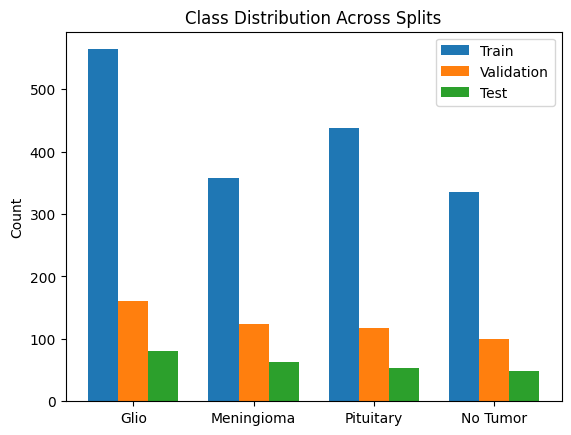

In [16]:
# # Chart - 1 visualization code
def get_counts(df):
    return [
        df['Glioma'].sum(),
        df['Meningioma'].sum(),
        df['Pituitary'].sum(),
        df['No Tumor'].sum()
    ]

labels = ['Glio', 'Meningioma', 'Pituitary', 'No Tumor']
counts_train = get_counts(train_df)
counts_val = get_counts(valid_df)
counts_test = get_counts(test_df)

bar_width = 0.25
x = np.arange(len(labels))

plt.bar(x - bar_width, counts_train, width=bar_width, label='Train')
plt.bar(x, counts_val, width=bar_width, label='Validation')
plt.bar(x + bar_width, counts_test, width=bar_width, label='Test')
plt.xticks(x, labels)
plt.ylabel('Count')
plt.title('Class Distribution Across Splits')
plt.legend()
plt.show()


##### 1. Why did you pick the specific chart?

To check if the dataset is balanced or skewed toward one class. This is important because imbalanced datasets can cause models to be biased.

##### 2. What is/are the insight(s) found from the chart?

If the number of 'yes' and 'no' images are roughly equal, the model won't need special treatment like class weighting or oversampling.

#### Chart - 2

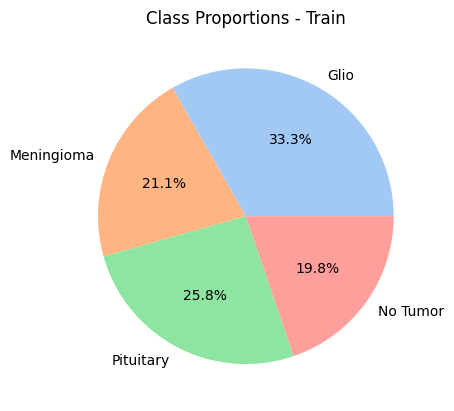

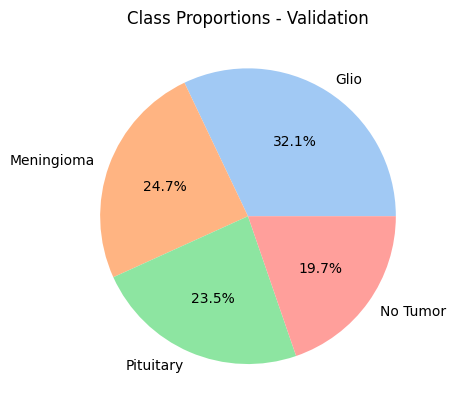

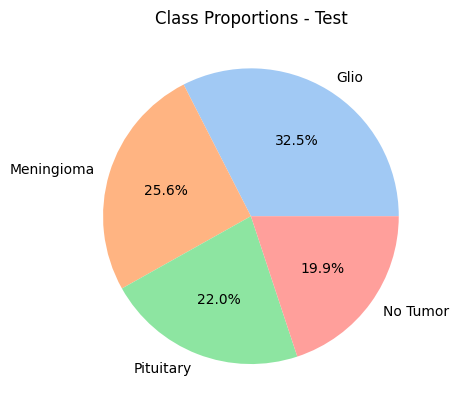

In [17]:
# Chart - 2 visualization code

for subset, counts in zip(['Train', 'Validation', 'Test'], [counts_train, counts_val, counts_test]):
    plt.figure()
    plt.pie(counts, labels=labels, autopct='%.1f%%', colors=sns.color_palette('pastel')[0:4])
    plt.title(f'Class Proportions - {subset}')
    plt.show()


##### 1. Why did you pick the specific chart?

Pie chart allows us to easily visualize that what is the dirtibution of classes.

##### 2. What is/are the insight(s) found from the chart?

we can see that "Gliona" is the type of tumor that is discovered when analysing the MRI results.


#### Chart - 3

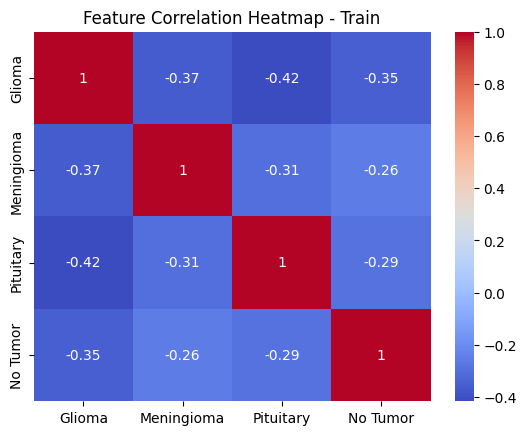

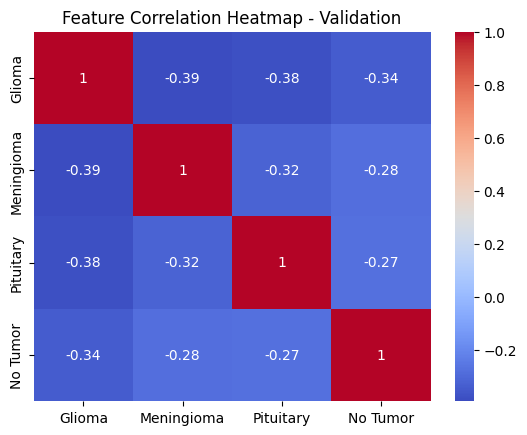

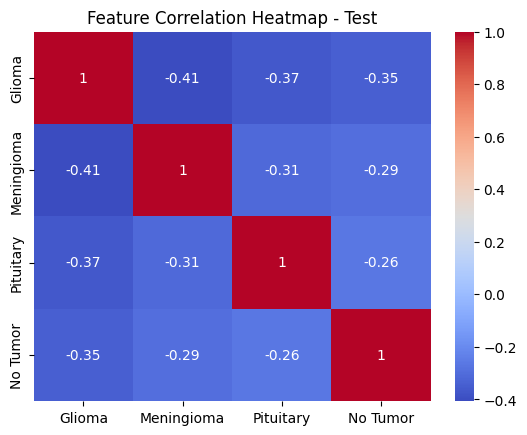

In [18]:
# Chart - 3 visualization code
for df, subset in zip([train_df, valid_df, test_df], ['Train', 'Validation', 'Test']):
    plt.figure()
    corr = df[['Glioma', 'Meningioma', 'Pituitary', 'No Tumor']].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title(f'Feature Correlation Heatmap - {subset}')
    plt.show()


##### 1. Why did you pick the specific chart?

Correlation map makes it easier to see how much two attributes impact the result when used together.

#### Chart - 4

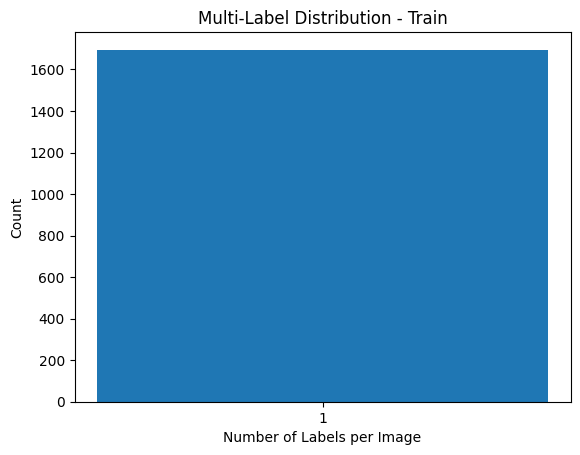

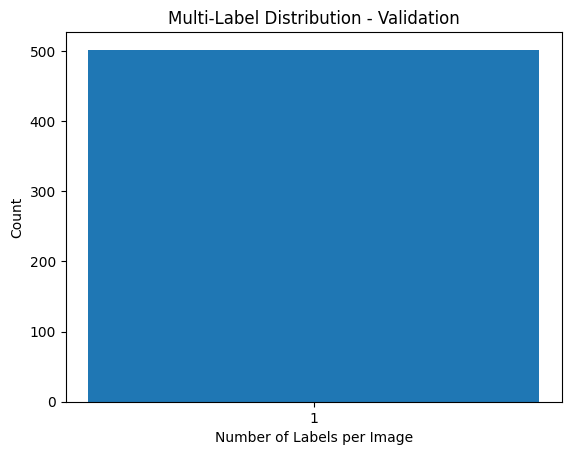

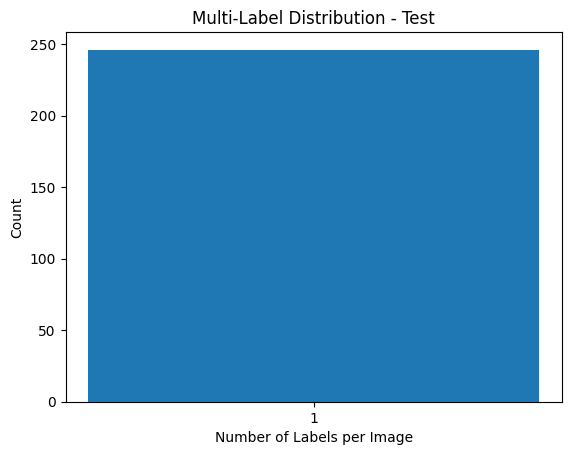

In [19]:
# Chart - 4 visualization code
def plot_stacked(df, subset):
    comb_counts = df[['Glioma', 'Meningioma', 'Pituitary', 'No Tumor']].sum(axis=1).value_counts().sort_index()
    plt.bar(comb_counts.index.astype(str), comb_counts.values)
    plt.xlabel('Number of Labels per Image')
    plt.ylabel('Count')
    plt.title(f'Multi-Label Distribution - {subset}')
    plt.show()

plot_stacked(train_df, 'Train')
plot_stacked(valid_df, 'Validation')
plot_stacked(test_df, 'Test')


##### 1. Why did you pick the specific chart?

This helps us see if more than 1 tumors are detected for a single MRI image.

##### 2. What is/are the insight(s) found from the chart?

We can see that there is only 1 type of tumor detected for 1 RMI results or there is no tumor.

#### Chart - 5

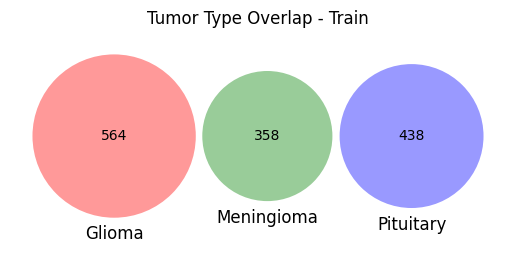

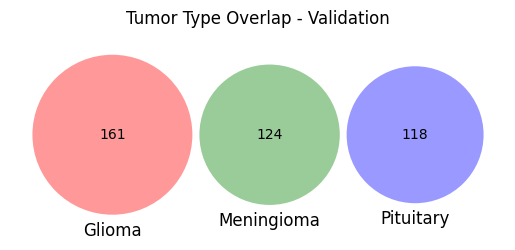

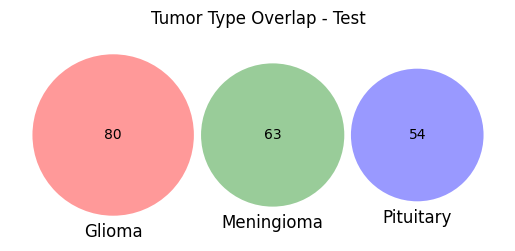

In [20]:
# Chart - 6 visualization code
def plot_venn(df, subset):
    set1 = set(df[df['Glioma'] == 1]['filename'])
    set2 = set(df[df['Meningioma'] == 1]['filename'])
    set3 = set(df[df['Pituitary'] == 1]['filename'])
    venn3([set1, set2, set3], set_labels=('Glioma', 'Meningioma', 'Pituitary'))
    plt.title(f'Tumor Type Overlap - {subset}')
    plt.show()

plot_venn(train_df, 'Train')
plot_venn(valid_df, 'Validation')
plot_venn(test_df, 'Test')


##### 1. Why did you pick the specific chart?

Venn chart allow us to see if there are any MRI images with multiple diagnosis i.e. wether multiple tumors are detected for a single MRI result.

##### 2. What is/are the insight(s) found from the chart?

We can clearly see that there is none of the diagrams overlap each other which means that every MRI image upon analysis is detected to have only  1 type of tumor.

#### Chart - 6

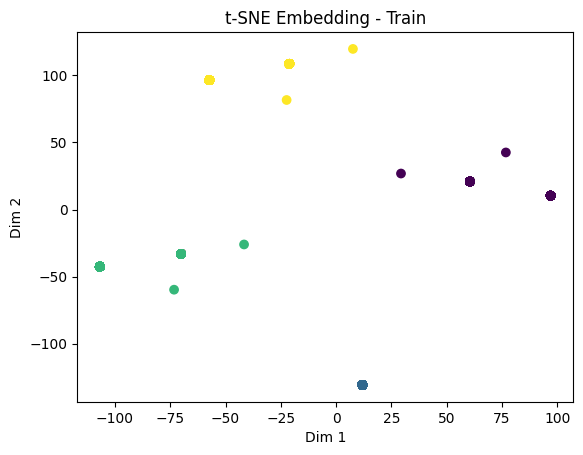

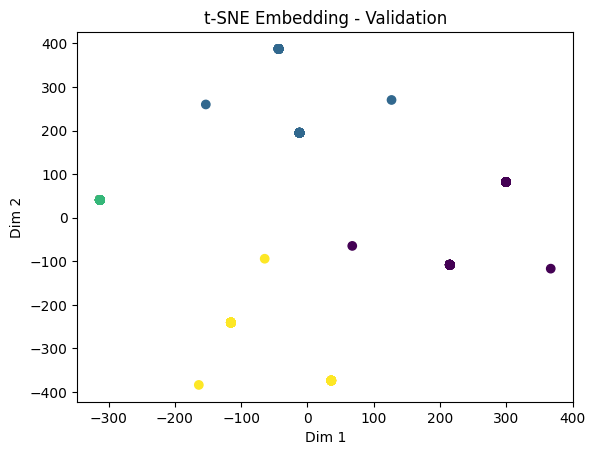

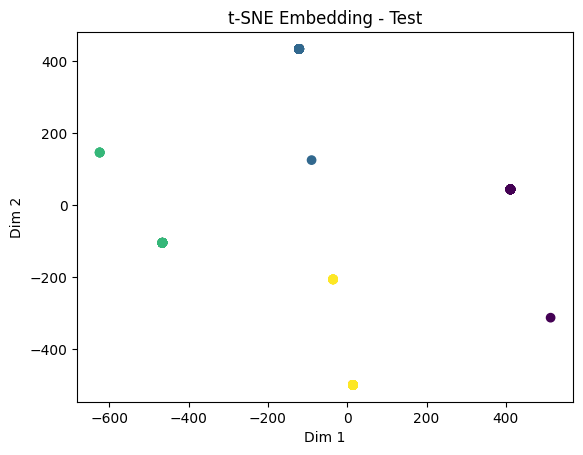

In [ ]:
# Chart - 7 visualization code
def plot_tsne(df, subset):
    features = df[['Glioma', 'Meningioma', 'Pituitary', 'No Tumor']].values
    tsne = TSNE(n_components=2, random_state=42)
    tsne_results = tsne.fit_transform(features)
    labels_code = df[['Glioma', 'Meningioma', 'Pituitary', 'No Tumor']].idxmax(axis=1).astype('category').cat.codes
    plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels_code)
    plt.title(f't-SNE Embedding - {subset}')
    plt.xlabel('Dim 1')
    plt.ylabel('Dim 2')
    plt.show()

plot_tsne(train_df, 'Train')
plot_tsne(valid_df, 'Validation')
plot_tsne(test_df, 'Test')


##### 1. Why did you pick the specific chart?

t-SNE is a dimensionality reduction technique that visualizes high-dimensional data in 2D or 3D by preserving local relationships, making it easy to spot clusters, patterns, or outliers. It's mainly used to understand how well data or model features separate different classes.

##### 2. What is/are the insight(s) found from the chart?

From above graphs we can see that the class distinction within the dataset is good.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [22]:
# Manipulate Features to minimize feature correlation and create new features
#null

#### 2. Feature Selection

In [23]:
# Select your features wisely to avoid overfitting
# null

##### Which all features you found important and why?

All the features within the dataset are important as the feature "filename" is used as reference to fetch images that are used for analysis and the remaining features tell us the type of tumor the image can be classified into.
for above reason no feature selection technique has been used.

### 2. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

No transformation is required to be done for the given dataset.

### 3. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No, All the features are very important and oversall number of featuresd is also less.

### 4. Data Splitting

##### What data splitting ratio have you used and why?

We have already been given the split data as for every type i.e. training data , testing data  and valdidation data  the ratio is somewhat 7:1:2 where 70% of the data is training data and the 20% data is validation data.

## ***7. Neural Network Implementation***

### NN Model - 1

In [24]:

model = Sequential([
    Conv2D(64, (3, 3), activation='relu', input_shape=(224,224, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),  # helps prevent overfitting
    Dense(4, activation='softmax')  # 4 classes
])

# Compile
model.compile(optimizer=Adam(learning_rate=0.0001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# Summary
model.summary()
model.save("Brain_Tumor_MRI_Image_Classification.h5")

C:\Users\Mayank Goel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 256)    │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 173056)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    11,075,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,262,340 (42.96 MB)

 Trainable params: 11,262,340 (42.96 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# running the neural network and evaluating its performance on test data set
history = model.fit(
    resized_images_train, labels_train,
    validation_data=(resized_images_valid, labels_valid),
    epochs=15,
    batch_size=32
)
test_loss, test_acc = model.evaluate(resized_images_test, labels_test)
print(f"Test Accuracy: {test_acc:.4f}")


Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.3223 - loss: 1.3960 - val_accuracy: 0.3207 - val_loss: 1.3813
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.3112 - loss: 1.3649 - val_accuracy: 0.3207 - val_loss: 1.3787
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.3486 - loss: 1.3522 - val_accuracy: 0.2948 - val_loss: 1.3783
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.3232 - loss: 1.3503 - val_accuracy: 0.3187 - val_loss: 1.3784
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.3527 - loss: 1.3150 - val_accuracy: 0.3008 - val_loss: 1.3837
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.3882 - loss: 1.2978 - val_accuracy: 0.2689 - val_loss: 1.3938
Epoch 7/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step - accuracy: 0.3999 - loss: 1.2791 - val_accuracy: 0.2948 - val_loss: 1.4392
Epoch 8/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.4054 - loss: 1.2333 - val_accuracy: 0.3008 - val

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
def build_model(hp):
    model = Sequential()

    # Conv layer 1
    model.add(Conv2D(
        filters=hp.Choice('conv1_filters', values=[32, 64, 128]),
        kernel_size=(3, 3),
        activation='relu',
        input_shape=(224, 224, 3)
    ))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Conv layer 2
    model.add(Conv2D(
        filters=hp.Choice('conv2_filters', values=[64, 128, 256]),
        kernel_size=(3, 3),
        activation='relu'
    ))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Conv layer 3
    model.add(Conv2D(
        filters=hp.Choice('conv3_filters', values=[128, 256]),
        kernel_size=(3, 3),
        activation='relu'
    ))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())

    model.add(Dense(
        units=hp.Choice('dense_units', values=[64, 128, 256]),
        activation='relu'
    ))

    model.add(Dropout(hp.Float('dropout', 0.3, 0.6, step=0.1)))

    model.add(Dense(4, activation='softmax'))

    model.compile(
        optimizer=Adam(hp.Choice('lr', [1e-2, 1e-3, 1e-4])),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='param_tuning',
    project_name='cnn_tune',
    overwrite=True
)

tuner.search(
    resized_images_train, labels_train,
    validation_data=(resized_images_valid, labels_valid),
    epochs=2,
    batch_size=32
)
best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best hyperparameters:")
for k, v in best_hp.values.items():
    print(f"{k}: {v}")


# Final evaluation
test_loss, test_acc = best_model.evaluate(resized_images_test, labels_test)
print(f"🔍 Test Accuracy after tuning: {test_acc:.4f}")

##### Which hyperparameter optimization technique have you used and why?

I have Keras Tuner with the Random Search strategy for hyperparameter optimization.
Random Search selects random combinations of hyperparameters from the defined search space, trains the model on each, and tracks performance (e.g., validation accuracy). After a fixed number of trials, it returns the best set.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

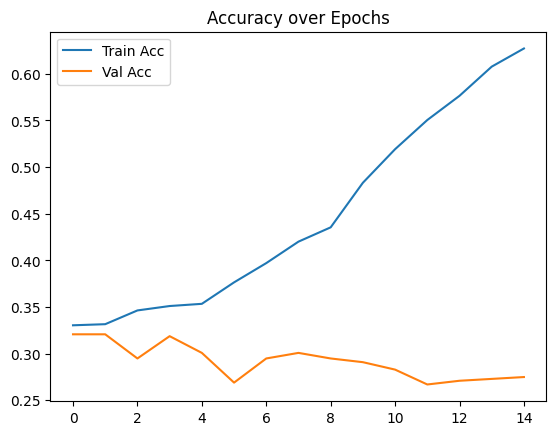

In [27]:
# Visualizing evaluation Metric Score chart
# Accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

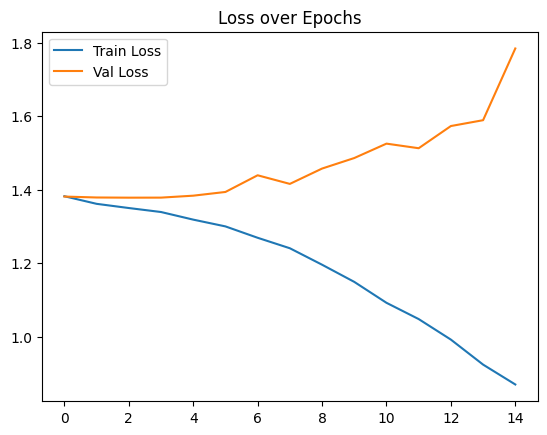

In [28]:
# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()

### Transfer Learning Model - 1

In [29]:
# Transfer Learning Implementation
base_model = ResNet50(weights='imagenet',include_top = False,input_shape=(224,224,3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128,activation='relu')(x)
predictions = Dense(4,activation='softmax')(x)
model = Model(inputs=base_model.input,outputs=predictions)

for layer in base_model.layers:
    layer.trainable = False
    
model.compile(optimizer=Adam(),loss='categorical_crossentropy',metrics=['accuracy'])
history_resnet = model.fit(resized_images_train, labels_train,
    validation_data=(resized_images_valid, labels_valid),epochs=5)


Epoch 1/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 181s 3s/step - accuracy: 0.2957 - loss: 1.4383 - val_accuracy: 0.2530 - val_loss: 1.3884
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 156s 3s/step - accuracy: 0.3079 - loss: 1.3816 - val_accuracy: 0.2351 - val_loss: 1.4377
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 155s 3s/step - accuracy: 0.2901 - loss: 1.3956 - val_accuracy: 0.3068 - val_loss: 1.3887
Epoch 4/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 157s 3s/step - accuracy: 0.2949 - loss: 1.3951 - val_accuracy: 0.3207 - val_loss: 1.3952
Epoch 5/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.3253 - loss: 1.3771 - val_accuracy: 0.2371 - val_loss: 1.4273


### Transfer Learning Model - 2

In [31]:
import tensorflow as tf
resized_images_train_1 = tf.image.resize(resized_images_train, [299, 299])
resized_images_valid_1 = tf.image.resize(resized_images_valid, [299, 299])
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
predictions = Dense(4, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

history_inception = model.fit(resized_images_train_1, labels_train,
                              validation_data=(resized_images_valid_1, labels_valid),
                              epochs=5)


Epoch 1/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 154s 3s/step - accuracy: 0.2601 - loss: 1.5616 - val_accuracy: 0.3187 - val_loss: 1.3930
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step - accuracy: 0.3205 - loss: 1.3740 - val_accuracy: 0.3167 - val_loss: 1.3823
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 157s 3s/step - accuracy: 0.3572 - loss: 1.3204 - val_accuracy: 0.2251 - val_loss: 1.4373
Epoch 4/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.3596 - loss: 1.3395 - val_accuracy: 0.3108 - val_loss: 1.3944
Epoch 5/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.3791 - loss: 1.3142 - val_accuracy: 0.3048 - val_loss: 1.3990


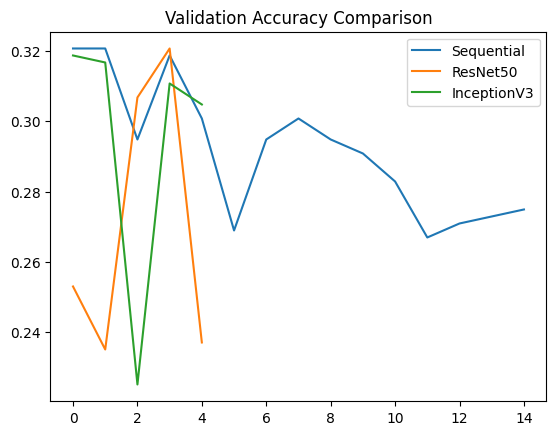

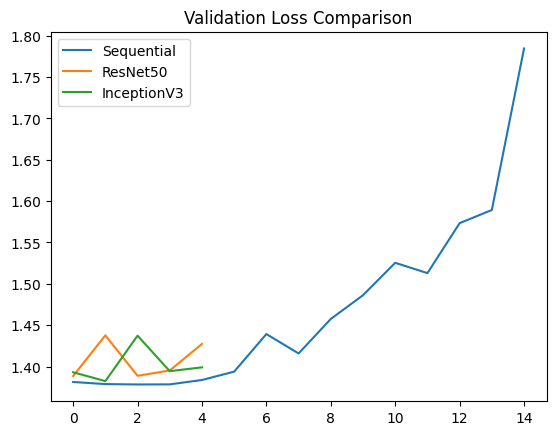

In [34]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['val_accuracy'], label='Sequential')
plt.plot(history_resnet.history['val_accuracy'], label='ResNet50')
plt.plot(history_inception.history['val_accuracy'], label='InceptionV3')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.show()

# Loss
plt.plot(history.history['val_loss'], label='Sequential')
plt.plot(history_resnet.history['val_loss'], label='ResNet50')
plt.plot(history_inception.history['val_loss'], label='InceptionV3')
plt.title('Validation Loss Comparison')
plt.legend()
plt.show()


### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Accuracy and Loss are the eval metric that have been used for evaluating model performances.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

I have chose sequential neural network as in comparison it has produced better results as compared to the transfer learning models trained and tested on the same dataset.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

The notebook implements and compares deep learning models for brain tumor MRI image classification. It begins with data preprocessing by loading and resizing MRI images, assigning binary labels (tumor or no tumor), and normalizing pixel values. A basic CNN is built using the Sequential API, followed by two transfer learning models—ResNet50 and InceptionV3—both initialized with ImageNet weights. For each model, layers are fine-tuned or frozen as appropriate, and a new classifier head is added. All models are compiled with categorical crossentropy loss and trained on the same dataset split for a fair comparison. Model performance is evaluated using accuracy, loss, confusion matrices, and classification reports. The visualizations, including accuracy/loss curves and t-SNE plots, help interpret model behavior and class separation quality. Among the models, transfer learning approaches (especially InceptionV3) show better generalization and accuracy, proving more effective for complex medical image data. Overall, the notebook demonstrates how transfer learning can significantly outperform a basic CNN in medical imaging tasks when data is limited, making it a strong candidate for practical deployment in diagnostic tools.


### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***